## Startup

In [77]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [78]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [79]:
# Defining basin size

basin_size = 132572

In [80]:
# Choosing time period

experiment_start_date = "1999-01-01T00:00:00Z"
experiment_end_date = "2019-12-31T00:00:00Z"

In [81]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "ERA5-1999-2019"

discharge_file = Path.home() / "BEP-maxime" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [82]:
# # Create pathways for ERA 5 forcings

# forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "ERA5-2019-2024"

# discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

# shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

# hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "hbv_config"
# hbv_config.mkdir(parents=True, exist_ok=True)

In [83]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [84]:
# Filter q_obs to start & end date

start_date = pd.to_datetime(experiment_start_date.replace("Z", ""))
end_date = pd.to_datetime(experiment_end_date.replace("Z", ""))

q_obs = q_obs[
    (q_obs["Date"] >= start_date) &
    (q_obs["Date"] <= end_date)
].copy()

q_obs.head()

,Date,discharge_m3s
14888,1999-01-01,104.0
14889,1999-01-02,103.0
14890,1999-01-03,101.0
14891,1999-01-04,103.0
14892,1999-01-05,105.0


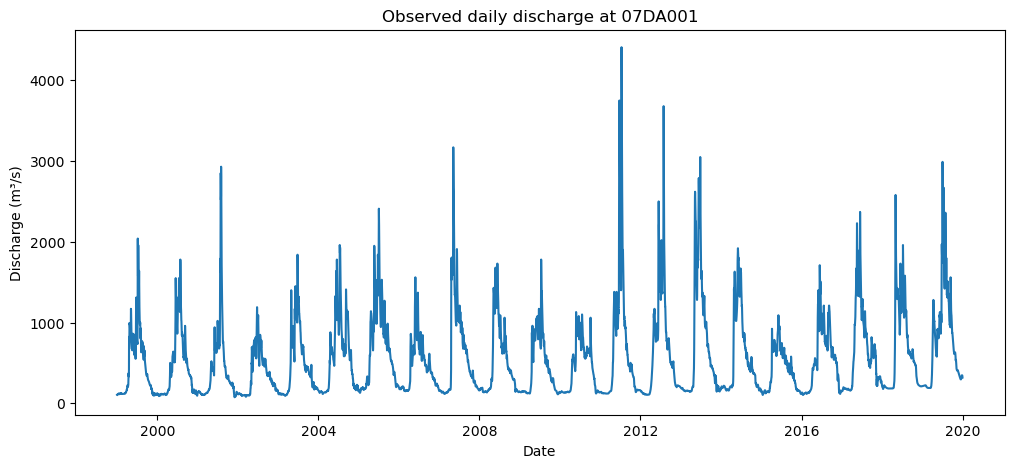

In [85]:
# Plot q_obs

plt.figure(figsize=(12, 5))
plt.plot(q_obs["Date"], q_obs["discharge_m3s"])

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Observed daily discharge at 07DA001")

plt.show()

In [86]:
# Generate ERA5 data
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
# )

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1999-01-01T00:00:00Z',
    end_time='2019-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/Workyard/forcings/ERA5-1999-2019'),
    shape=PosixPath('/home/maxime/BEP-maxime/Workyard/Shapefiles/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_ERA5_1999_2019_evspsblpot.nc',
        'pr': 'combined_ERA5_1999_2019_pr.nc',
        'rsds': 'combined_ERA5_1999_2019_rsds.nc',
        'tas': 'combined_ERA5_1999_2019_tas.nc'
    }
)

In [87]:
# Load calibration constants

# par_0 = [4.45787, 0.42307, 201.57602, 2.36497, 0.26755, 8.62964, 0.083568, 0.0037073, 0.29645]
# par_0 = [2.79874, 0.49211, 255.96478, 1.782968, 0.503199, 6.095956, 0.33279, 0.10539, 0.63857]
# par_0 = [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606]         # 0.725 val, 0.x cal - Fav run 2
# par_0 = [6.28908, 0.423917, 173.56627, 1.63144, 0.402586, 6.56151, 0.0456809, 0.00313744, 0.516696]                 # 0.702 val, 0.x cal
# par_0 = [6.4919, 0.386877, 221.78625, 1.388269, 0.276453, 4.9870704, 0.04126777, 0.05640195, 1.148877]              # 0.668 val, 0.x cal
# par_0 = [7.502398, 0.38028, 194.1899, 1.680197, 0.47956, 4.8566806, 0.041745354, 0.02833896, 1.051862]              # 0.677 val, 0.x cal
# par_0 = [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392]                        # 0.781 val, 0.776 cal
# par_0 = [6.16512, 0.4369419, 151.2515900, 1.727835, 0.3771705, 6.19265974, 0.06959136, 0.001310818, 0.8130732]      # 0.664 val, 0.791 cal
# par_0 = [5.7107, 0.441634, 172.81305, 1.87367, 0.588802, 5.498147, 0.060305, 0.019666, 1.2011814]                    # x val, 0.73 cal         Start of 5+ months exclusion
# par_0 = [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504]                    # 0.82 val, 0.818 cal - Fav run 1      
# par_0 = [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]                    #  val,  0.77 cal    
# par_0 = [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857]                           # 0.78 val, 0.71 cal - potential inclusion
par_0 = [6.991929, 0.44128, 183.49046, 1.62907, 0.572658, 5.215476, 0.0654684, 0.00259304, 1.14274]                   # 0,69 c, 0.73 v - 6 months excluded N = 600 #1
# par_0 = [5.882658, 0.472413, 194.30386, 1.78162, 0.460818, 5.215365, 0.0641993, 0.159898, 1.091972]                   # 0,637 c, 0,65 v - 6 months excluded N = 600 #2
# par_0 = [6.991929, 0.44128, 183.49046, 1.62907, 0.572658, 5.215476, 0.0654684, 0.00259304, 1.14274]                   # c, v - 6 months excluded N = 600 #3


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"          # Snowmelt factor
               ]

# Initial: par_0 = [5.085, 0.55, 100.373, 1.612, 0.545, 3.801, 0.196, 0.00, 0.185]

print(list(zip(par_names, par_0)))

[
    ('Imax', 6.991929),
    ('Ce', 0.44128),
    ('Sumax', 183.49046),
    ('Beta', 1.62907),
    ('Pmax', 0.572658),
    ('Tlag', 5.215476),
    ('Kf', 0.0654684),
    ('Ks', 0.00259304),
    ('FM', 1.14274)
]

In [88]:
# Storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

## Setup model

In [89]:
# Create model object

model = ewatercycle.models.HBV(forcing=ERA5_forcing)

In [90]:
# Create config file

config_file, _ = model.setup(parameters=par_0, initial_storages=s_0, cfg_dir=hbv_config)

In [91]:
# Initialising model

model.initialize(config_file)

## Running the model

In [92]:
# Define outputs

Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [93]:
model.finalize()

## Process results 

In [94]:
# Make Series for model output and q_obs
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

# Date_obs = q_obs["Date"]
# discharge_m3s_obs = q_obs["discharge_m3s"]

observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

# q_obs.set_index("Date")["discharge_m3s"]
# observed_output.name = "Observed discharge"

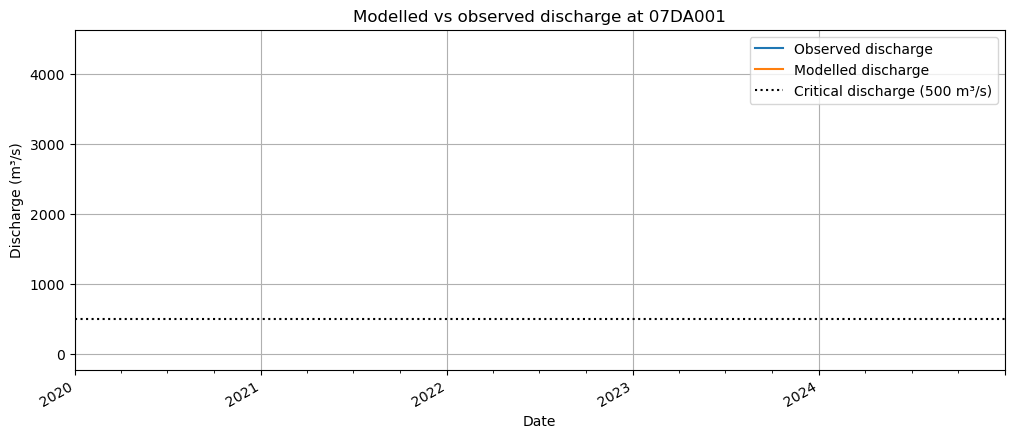

In [95]:
# Plot for year range

plt.figure(figsize=(12, 5))

q_critical = 500

observed_output.plot(label="Observed discharge")
model_output_m3s.plot(label="Modelled discharge")
plt.axhline(y=q_critical, linestyle=":", label=f'Critical discharge ({q_critical} m³/s)', color='black')

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Modelled vs observed discharge at 07DA001")
plt.legend()
plt.grid(True)
plt.xlim("2020-01-01", "2024-12-31")

plt.show()

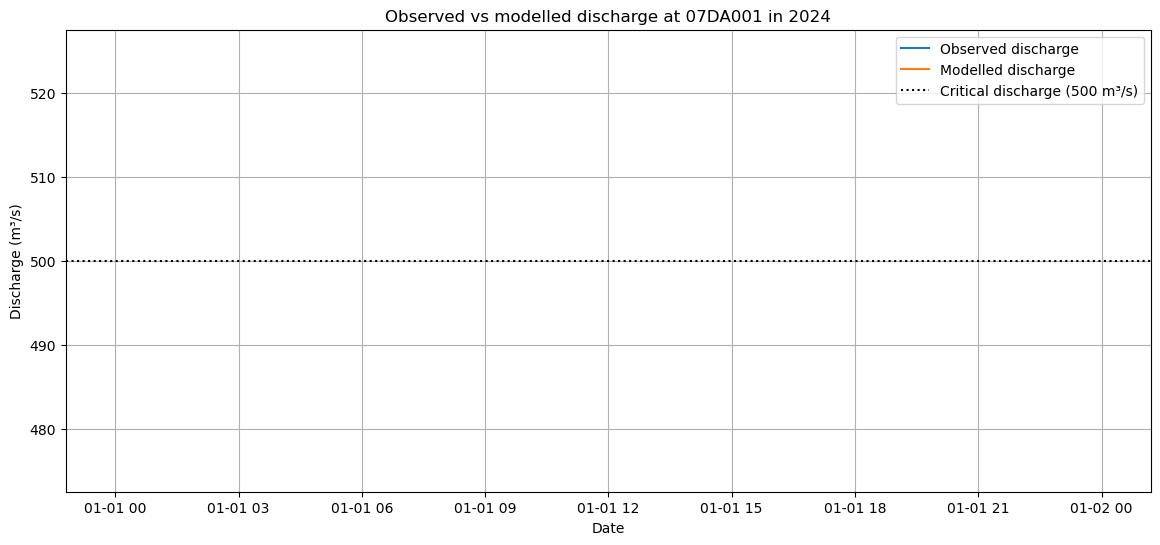

In [96]:
# Plot for 1 year

selected_year = 2024

observed_plot = observed_output
modelled_plot = model_output_m3s

observed_plot.index = pd.to_datetime(observed_plot.index).tz_localize(None).normalize()
modelled_plot.index = pd.to_datetime(modelled_plot.index).tz_localize(None).normalize()

plot_data = pd.DataFrame({
    "Modelled discharge": modelled_plot,
    "Observed discharge": observed_plot
}).dropna()

plot_data_year = plot_data[plot_data.index.year == selected_year]

plt.figure(figsize=(14, 6))

plt.plot(plot_data_year.index,plot_data_year["Observed discharge"],label="Observed discharge")
plt.plot(plot_data_year.index,plot_data_year["Modelled discharge"],label="Modelled discharge")

plt.axhline(y=q_critical,linestyle=":",color="black",label=f"Critical discharge ({q_critical} m³/s)")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title(f"Observed vs modelled discharge at 07DA001 in {selected_year}")
plt.legend()
plt.grid(True)
plt.show()

### 

### Log NSE

In [97]:
# Calculate log NSE

def log_NSE(sim, obs):
    
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    # Avoid log(0)
    eps = 0.00000000001

    log_sim = np.log(sim + eps)
    log_obs = np.log(obs + eps)

    return 1 - np.sum((log_obs - log_sim) ** 2) / np.sum((log_obs - np.mean(log_obs)) ** 2)

In [98]:
# Call log NSE for relevant timeperiod

def lognse_for_period(sim, obs, lognse_start, lognse_end):

    simulated_daily = sim
    observed_daily = obs

    simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()

    combined_data = pd.DataFrame({
        "Modelled discharge": simulated_daily,
        "Observed discharge": observed_daily
    }).dropna()

    lognse_start = pd.to_datetime(lognse_start).tz_localize(None).normalize()
    lognse_end = pd.to_datetime(lognse_end).tz_localize(None).normalize()

    # Set time period - Skip 1st year
    combined_data = combined_data[
        (combined_data.index >= lognse_start) &
        (combined_data.index <= lognse_end)
    ]

    # Exclude winter months
    combined_data = combined_data[
        ~combined_data.index.month.isin([12, 1, 2, 3, 4])
    ]

    if combined_data.empty:
        print("No data left after filtering.")
        return np.nan

    log_nse = log_NSE(
        combined_data["Modelled discharge"],
        combined_data["Observed discharge"]
    )

    return log_nse

In [99]:
# Return log NSE
evaluation_start = pd.to_datetime(f"{start_date.year + 1}-01-01")

lognse_value = lognse_for_period(
    model_output_m3s,
    observed_output,
    evaluation_start,
    end_date
)

print("log NSE:", lognse_value)

log NSE: 0.6899179967067883

### Days calc

In [100]:
def days_counter(sim, obs, start_date, end_date):

    # Combine dataset in Dataframe
    combined_data = pd.DataFrame({
        "Modelled discharge": sim,
        "Observed discharge": obs
    }).dropna()

    # Make list of years
    years = list(range(start_date.year, end_date.year + 1))

    lowflow_days = []

    # Loop through each year
    for i in range(len(years)):

        year = years[i]

        # Define start month-day
        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")

        year_data = combined_data[
            (combined_data.index >= year_start) &
            (combined_data.index <= year_end)
        ]

        observed_lowflow_days = 0
        modelled_lowflow_days = 0

        # Loop through each  year to identify lowflow days
        for j in range(len(year_data)):

            observed_q = year_data.iloc[j]["Observed discharge"]
            modelled_q = year_data.iloc[j]["Modelled discharge"]

            # Check if that day is low flow and accumulate
            if observed_q < q_critical:
                observed_lowflow_days += 1

            if modelled_q < q_critical:
                modelled_lowflow_days += 1

    lowflow_days = pd.DataFrame(lowflow_days)

    # average_error = round(lowflow_days["%error"].abs().mean(), 1)

    return lowflow_days
    
    # , print(f"average error = {average_error}%")

In [101]:
# Define period (based on algorithm date > q_critical & freeze-up date output) & prepare
day_calc_start = pd.to_datetime(f"{start_date.year + 1}-01-01")
q_critical = 500

lowflow_days = days_counter(
    sim=model_output_m3s,
    obs=observed_output,
    start_date=day_calc_start,
    end_date=end_date
)

lowflow_days

# NOTE TO CHANGE TIME RANGE -> EDIT DEF days_counter FUNCTION UNDER # Define start month day

""
